In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [ ]:

train_dir = "/kaggle/input/datasets/jayaprakashpondy/kidney-cancer-image/DATASET/train"
val_dir   = "/kaggle/input/datasets/jayaprakashpondy/kidney-cancer-image/DATASET/val"

The input size must be (224,224,3)

In [ ]:
img_size = (224, 224)
batch_size = 32

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 4710 images belonging to 2 classes.
Found 1177 images belonging to 2 classes.
Found 1473 images belonging to 2 classes.


In [ ]:
print("Class labels:", train_generator.class_indices)

Class labels: {'Normal': 0, 'Tumor': 1}


to prevent Overfitting early stopping is used where training automatically stops when there is no improvement

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

VGG16

vgg16 :16 layers where 13 convolution layer and 3 dense layer

In [ ]:

vgg16_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg16_base.layers:
    layer.trainable = False

In [ ]:
vgg16_model = Sequential()

vgg16_model.add(vgg16_base)
vgg16_model.add(Flatten())

vgg16_model.add(Dense(256, activation='relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.5))

vgg16_model.add(Dense(128, activation='relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.3))

vgg16_model.add(Dense(1, activation='sigmoid'))

In [ ]:
vgg16_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg16 = vgg16_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 84s 539ms/step - accuracy: 0.7669 - loss: 0.4999 - val_accuracy: 0.8258 - val_loss: 0.5134
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 503ms/step - accuracy: 0.9557 - loss: 0.1267 - val_accuracy: 0.7681 - val_loss: 0.6579
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 74s 502ms/step - accuracy: 0.9790 - loss: 0.0583 - val_accuracy: 0.8114 - val_loss: 0.6818
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 496ms/step - accuracy: 0.9793 - loss: 0.0602 - val_accuracy: 0.8717 - val_loss: 0.4022
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 493ms/step - accuracy: 0.9903 - loss: 0.0324 - val_accuracy: 0.8190 - val_loss: 0.6102
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 74s 502ms/step - accuracy: 0.9846 - loss: 0.0439 - val_accuracy: 0.8539 - val_loss: 0.4064
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 494ms/step - accuracy: 0.9892 - loss: 0.0280 - val_accuracy: 0.8573 - val_loss: 0.3900
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 506ms/step - accuracy: 0.9902 - loss: 0

VGG19

vgg19 :19 layers where 16 convolution layer and 3 dense layer

In [ ]:

vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg19_base.layers:
    layer.trainable = False

In [ ]:
vgg19_model = Sequential()

vgg19_model.add(vgg19_base)
vgg19_model.add(Flatten())

vgg19_model.add(Dense(256, activation='relu'))
vgg19_model.add(BatchNormalization())
vgg19_model.add(Dropout(0.5))

vgg19_model.add(Dense(128, activation='relu'))
vgg19_model.add(BatchNormalization())
vgg19_model.add(Dropout(0.3))

vgg19_model.add(Dense(1, activation='sigmoid'))

In [ ]:
vgg19_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg19 = vgg19_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 84s 536ms/step - accuracy: 0.7772 - loss: 0.5033 - val_accuracy: 0.7171 - val_loss: 0.9487
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 513ms/step - accuracy: 0.9604 - loss: 0.1143 - val_accuracy: 0.7587 - val_loss: 0.7435
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 510ms/step - accuracy: 0.9660 - loss: 0.0950 - val_accuracy: 0.7799 - val_loss: 0.7662
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 510ms/step - accuracy: 0.9818 - loss: 0.0468 - val_accuracy: 0.8250 - val_loss: 0.6096
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 507ms/step - accuracy: 0.9764 - loss: 0.0620 - val_accuracy: 0.7995 - val_loss: 0.8651
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.9874 - loss: 0.0414 - val_accuracy: 0.8751 - val_loss: 0.5046
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 508ms/step - accuracy: 0.9840 - loss: 0.0481 - val_accuracy: 0.7536 - val_loss: 0.9325
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 509ms/step - accuracy: 0.9894 - loss: 0

ResNet50

ResNet50: 50 layers 49 convolution layers and 1 dense layer

In [ ]:

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in resnet_base.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
resnet_model = Sequential()

resnet_model.add(resnet_base)
resnet_model.add(Flatten())

resnet_model.add(Dense(256, activation='relu'))
resnet_model.add(BatchNormalization())
resnet_model.add(Dropout(0.5))

resnet_model.add(Dense(128, activation='relu'))
resnet_model.add(BatchNormalization())
resnet_model.add(Dropout(0.3))

resnet_model.add(Dense(1, activation='sigmoid'))

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 101s 590ms/step - accuracy: 0.6986 - loss: 0.6223 - val_accuracy: 0.7553 - val_loss: 1.1849
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.8640 - loss: 0.3185 - val_accuracy: 0.7901 - val_loss: 0.4673
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 519ms/step - accuracy: 0.9131 - loss: 0.2084 - val_accuracy: 0.7485 - val_loss: 0.7829
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 507ms/step - accuracy: 0.9203 - loss: 0.1989 - val_accuracy: 0.7833 - val_loss: 0.5669
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 507ms/step - accuracy: 0.9348 - loss: 0.1569 - val_accuracy: 0.8326 - val_loss: 0.5323


In [ ]:

vgg16_loss, vgg16_acc = vgg16_model.evaluate(test_generator)
vgg19_loss, vgg19_acc = vgg19_model.evaluate(test_generator)
resnet_loss, resnet_acc = resnet_model.evaluate(test_generator)

print("VGG16 Accuracy:", vgg16_acc)
print("VGG19 Accuracy:", vgg19_acc)
print("ResNet50 Accuracy:", resnet_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 339ms/step - accuracy: 0.9718 - loss: 0.0996
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.9838 - loss: 0.0683
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8593 - loss: 0.4199
VGG16 Accuracy: 0.9701290130615234
VGG19 Accuracy: 0.9579090476036072
ResNet50 Accuracy: 0.8710115551948547


In [ ]:


import numpy as np


true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Class Labels:", class_labels)

Class Labels: ['Normal', 'Tumor']


In [ ]:
vgg16_predictions = vgg16_model.predict(test_generator)

vgg16_predicted_classes = (vgg16_predictions > 0.5).astype("int32").flatten()

print("VGG16 Predicted Classes:")
print(vgg16_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step
VGG16 Predicted Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
vgg19_predictions = vgg19_model.predict(test_generator)

vgg19_predicted_classes = (vgg19_predictions > 0.5).astype("int32").flatten()

print("VGG19 Predicted Classes:")
print(vgg19_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step
VGG19 Predicted Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
resnet_predictions = resnet_model.predict(test_generator)

resnet_predicted_classes = (resnet_predictions > 0.5).astype("int32").flatten()

print("ResNet50 Predicted Classes:")
print(resnet_predicted_classes[:20])

print("Actual Classes:")
print(true_classes[:20])

47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step
ResNet50 Predicted Classes:
[0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
Actual Classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


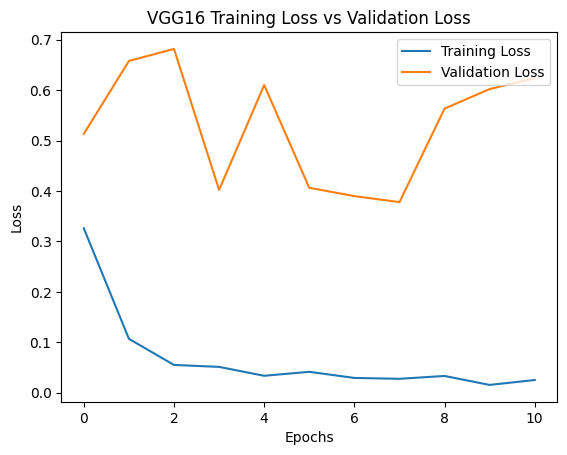

In [ ]:
plt.plot(history_vgg16.history['loss'], label='Training Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')

plt.title("VGG16 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

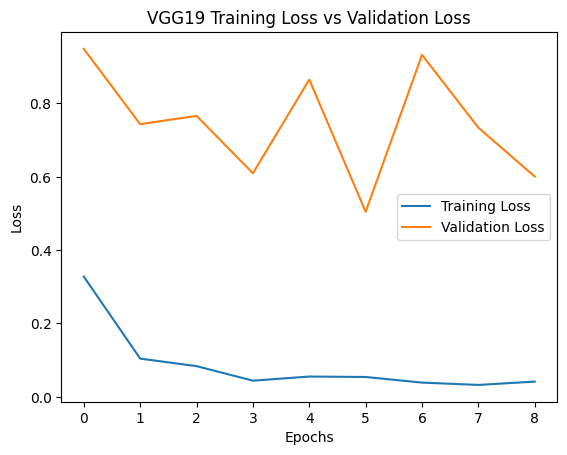

In [ ]:
plt.plot(history_vgg19.history['loss'], label='Training Loss')
plt.plot(history_vgg19.history['val_loss'], label='Validation Loss')

plt.title("VGG19 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

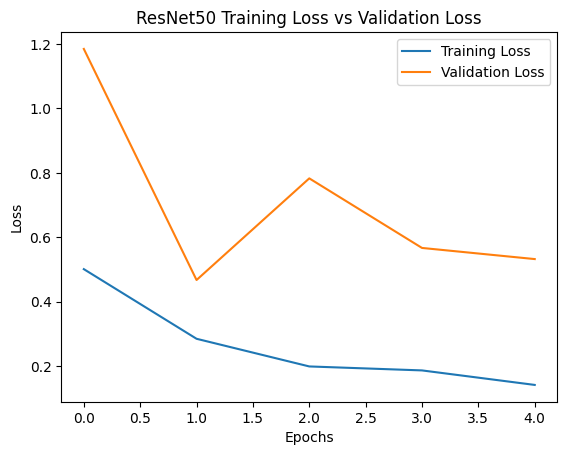

In [ ]:
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')

plt.title("ResNet50 Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

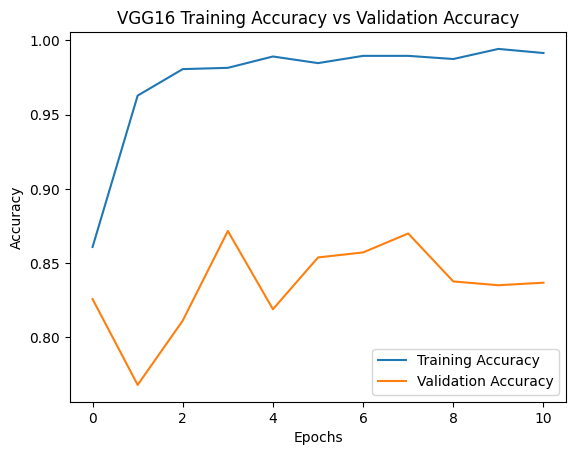

In [ ]:
plt.plot(history_vgg16.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

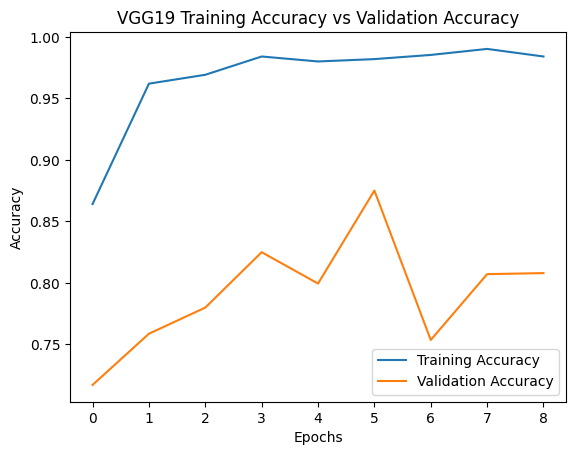

In [ ]:
plt.plot(history_vgg19.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG19 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

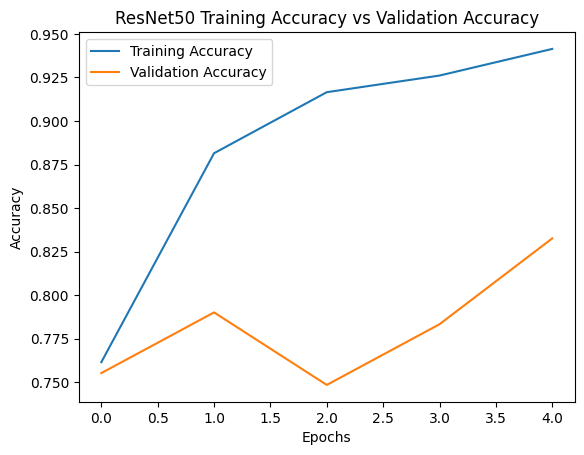

In [ ]:
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')

plt.title("ResNet50 Training Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

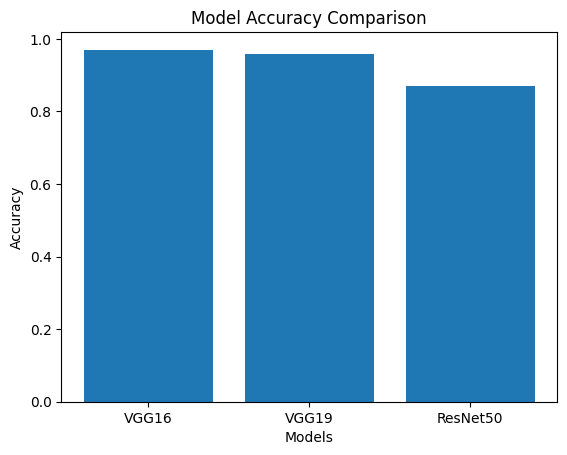

In [ ]:
models = ['VGG16', 'VGG19', 'ResNet50']
accuracies = [vgg16_acc, vgg19_acc, resnet_acc]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction: Normal


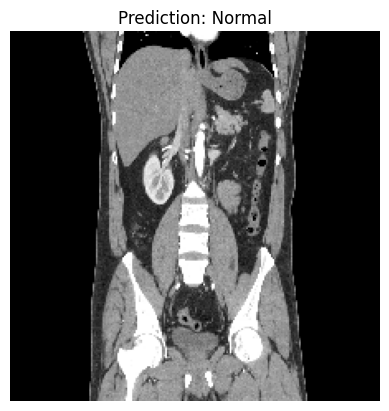

In [ ]:


img_path = "/kaggle/input/datasets/jayaprakashpondy/kidney-cancer-image/DATASET/val/Normal/Normal- (1005).jpg"


img = image.load_img(img_path, target_size=(224, 224))


img_array = image.img_to_array(img)


img_array = img_array / 255.0


img_array = np.expand_dims(img_array, axis=0)


prediction = vgg16_model.predict(img_array)


if prediction[0][0] > 0.5:
    print("Prediction: Tumor (Cancerous)")
else:
    print("Prediction: Normal")


plt.imshow(img)
plt.axis('off')

plt.title(
    "Prediction: Tumor"
    if prediction[0][0] > 0.5
    else "Prediction: Normal"
)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction: Normal


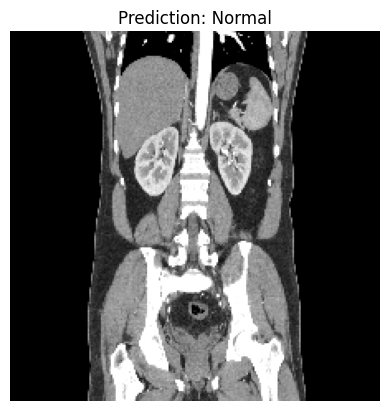

In [ ]:
img_path = "/kaggle/input/datasets/jayaprakashpondy/kidney-cancer-image/DATASET/val/Normal/Normal- (1028).jpg"


img = image.load_img(img_path, target_size=(224, 224))


img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


prediction = vgg16_model.predict(img_array)


if prediction[0][0] > 0.5:
    result = "Tumor (Cancerous)"
else:
    result = "Normal"

print("Prediction:", result)


plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + result)
plt.show()